# Prognóstico de sobrevida em câncer de pulmão — Árvore de Decisão

**Trabalho 1 — Inteligência Artificial II — 2026/02**
Faculdade Antonio Meneghetti (AMF) — Sistemas de Informação

---

Classificação binária supervisionada: estimar, **no momento do diagnóstico**, se um paciente
com câncer de pulmão sobreviverá.

Este notebook usa **um único modelo — a Árvore de Decisão** — e termina desenhando a árvore
treinada. A escolha é deliberada: entre todos os modelos testados, a árvore é a única cujo
raciocínio pode ser lido inteiro, nó por nó, sem nenhuma ferramenta auxiliar.

**Roteiro**

| Seção | O que faz |
|---|---|
| 1–2 | Configuração, carga dos dados e verificações de sanidade |
| 3 | Análise exploratória mínima |
| 4 | Remoção das variáveis com vazamento — a decisão central do trabalho |
| 5–6 | Pré-processamento dentro do Pipeline e divisão treino/teste |
| 7–8 | Treino da árvore e ajuste da profundidade |
| 9 | Avaliação no conjunto de teste, tocado uma única vez |
| 10 | **A árvore desenhada** |
| 11 | Importância das variáveis |
| 12 | **Por que o modelo se resume a uma variável** — três testes comparativos |
| 13 | Conclusões |

In [11]:
# Download do dataset (Kaggle). Se o arquivo já estiver local, basta apontar CSV_PATH.
import kagglehub

path = kagglehub.dataset_download("laxmikantaroy/lung-cancer-risk-factors-and-survival-dataset")
CSV_PATH = path + "/lung_cancer_dataset.csv"
print("CSV:", CSV_PATH)

Using Colab cache for faster access to the 'lung-cancer-risk-factors-and-survival-dataset' dataset.
CSV: /kaggle/input/lung-cancer-risk-factors-and-survival-dataset/lung_cancer_dataset.csv


In [12]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 60)
plt.rcParams.update({"figure.dpi": 110, "font.size": 9, "axes.grid": True,
                     "grid.alpha": 0.25, "axes.spines.top": False,
                     "axes.spines.right": False})

C_POS, C_NEG = "#2e86c1", "#cb4335"   # sobreviveu / não sobreviveu
print("ambiente: ok")

ambiente: ok


---
## 1. Configuração

Todas as constantes do trabalho ficam nesta célula. Nenhuma outra célula as redefine.

A parte mais importante é a **política de exclusão de colunas**. O problema foi definido como
prognóstico *no momento do diagnóstico*, e isso determina o que pode entrar no modelo: toda
variável que só passa a existir depois desse instante é vazamento e precisa sair **antes de
qualquer divisão dos dados**.

In [13]:
RANDOM_STATE = 42     # semente única: rodar duas vezes dá exatamente o mesmo resultado
TEST_SIZE = 0.20      # 20% reservados para o teste final
N_SPLITS = 5          # folds da validação cruzada
SCORING = "roc_auc"   # métrica que decide todas as escolhas

TARGET = "Survived"
TARGET_MAP = {"No": 0, "Yes": 1}     # classe positiva = sobreviveu

# ---------------- política de exclusão de colunas ----------------
LEAKY = [
    "Survival_Months",   # vazamento de alvo: é o desfecho em outra escala
    "Treatment",         # vazamento temporal: decidido DEPOIS do diagnóstico
]
IDENTIFIERS = ["Patient_ID", "Diagnosis_Date"]
REDUNDANT = [
    "Age_Group",       # discretização exata de Age
    "BMI_Category",    # discretização exata de BMI
    "Country",         # 60 níveis; WHO_Region preserva o sinal geográfico
]
DROP_ALWAYS = LEAKY + IDENTIFIERS + REDUNDANT

# ---------------- schema ----------------
NUMERIC_FEATURES = [
    "Diagnosis_Year", "Age", "Cigarettes_Per_Day", "Years_Smoking", "Pack_Years",
    "BMI", "Risk_Factor_Count", "Symptom_Count", "Tumor_Size_cm",
]
BINARY_FEATURES = [
    "Secondhand_Smoke", "Family_History", "Occupational_Hazard", "Chronic_Lung_Disease",
    "Asbestos_Exposure", "Radon_Exposure", "Previous_Cancer_History", "Coughing",
    "Shortness_of_Breath", "Chest_Pain", "Coughing_Blood", "Fatigue", "Weight_Loss",
    "Wheezing", "Recurrent_Infections", "Swallowing_Difficulty", "Finger_Clubbing",
    "Metastasis",
]
CATEGORICAL_FEATURES = [
    "WHO_Region", "Gender", "Smoking_Status", "Air_Pollution_Exposure", "Alcohol_Use",
    "Exercise_Frequency", "Genetic_Mutation", "Cancer_Type", "NSCLC_Subtype",
    "Cancer_Stage", "Diagnosis_Method",
]

# categóricas com ordem real -> codificação ordinal (a árvore corta em <= limiar)
ORDINAL_SPEC = {
    "Cancer_Stage":           ["Stage I", "Stage II", "Stage III", "Stage IV"],
    "Air_Pollution_Exposure": ["Low", "Moderate", "High"],
    "Alcohol_Use":            ["No Alcohol", "Moderate", "Heavy"],
    "Exercise_Frequency":     ["Low", "Moderate", "High"],
    "Smoking_Status":         ["Never Smoked", "Former Smoker", "Current Smoker"],
}
NOMINAL = [c for c in CATEGORICAL_FEATURES if c not in ORDINAL_SPEC]
STAGE_ORDER = ORDINAL_SPEC["Cancer_Stage"]

print(f"Colunas removidas antes de qualquer divisão: {len(DROP_ALWAYS)}")
for c in DROP_ALWAYS:
    print("   -", c)

Colunas removidas antes de qualquer divisão: 7
   - Survival_Months
   - Treatment
   - Patient_ID
   - Diagnosis_Date
   - Age_Group
   - BMI_Category
   - Country


---
## 2. Carga e verificações de sanidade

Quatro verificações que **interrompem a execução** se falharem. A ideia é que seja impossível
treinar um modelo sobre dados que violem o contrato — se algo mudar no arquivo de origem, o
notebook para aqui em vez de produzir um resultado silenciosamente errado.

In [14]:
df = pd.read_csv(CSV_PATH)
print(f"Dimensões: {df.shape[0]} linhas x {df.shape[1]} colunas\n")

# R1 — todas as colunas esperadas existem
esperadas = [TARGET] + NUMERIC_FEATURES + BINARY_FEATURES + CATEGORICAL_FEATURES
faltando = [c for c in esperadas if c not in df.columns]
assert not faltando, f"colunas ausentes: {faltando}"
print("R1 schema           : OK  — todas as colunas esperadas presentes")

# R2 — alvo binário e sem ausentes
assert set(df[TARGET].unique()) == {"No", "Yes"}, "alvo fora do vocabulário"
print(f"R2 alvo             : OK  — binário, {(df[TARGET]=='Yes').mean():.1%} de positivos")

# R3 — sem valores ausentes e sem duplicatas
assert df.isna().sum().sum() == 0, "existem valores ausentes"
assert df.drop(columns=["Patient_ID"]).duplicated().sum() == 0, "existem linhas duplicadas"
print("R3 integridade      : OK  — zero ausentes, zero duplicatas")

# R4 — numéricas dentro de faixas clinicamente plausíveis
FAIXAS = {"Age": (18, 110), "BMI": (10, 70), "Tumor_Size_cm": (0.1, 30),
          "Pack_Years": (0, 300), "Symptom_Count": (0, 10)}
for c, (lo, hi) in FAIXAS.items():
    assert df[c].between(lo, hi).all(), f"{c} fora da faixa plausível"
print("R4 faixas           : OK  — nenhum valor clinicamente impossível")

Dimensões: 2000 linhas x 46 colunas

R1 schema           : OK  — todas as colunas esperadas presentes
R2 alvo             : OK  — binário, 37.8% de positivos
R3 integridade      : OK  — zero ausentes, zero duplicatas
R4 faixas           : OK  — nenhum valor clinicamente impossível


In [15]:
df.head(4).T.head(25)

,0,1,2,3
Patient_ID,LC-0001,LC-0002,LC-0003,LC-0004
Diagnosis_Year,2020,2021,2017,2018
Diagnosis_Date,2020-11-04,2021-12-09,2017-04-05,2018-11-24
WHO_Region,Western Pacific,Americas,Western Pacific,Western Pacific
Country,China,Mexico,Japan,Singapore
Age,46,71,53,55
Age_Group,40-49,70-79,50-59,50-59
Gender,Female,Male,Female,Male
Smoking_Status,Current Smoker,Former Smoker,Never Smoked,Current Smoker
Cigarettes_Per_Day,28,5,0,21


---
## 3. Análise exploratória

Só o necessário para entender o problema: como o alvo se distribui e quais variáveis têm
alguma associação com ele.

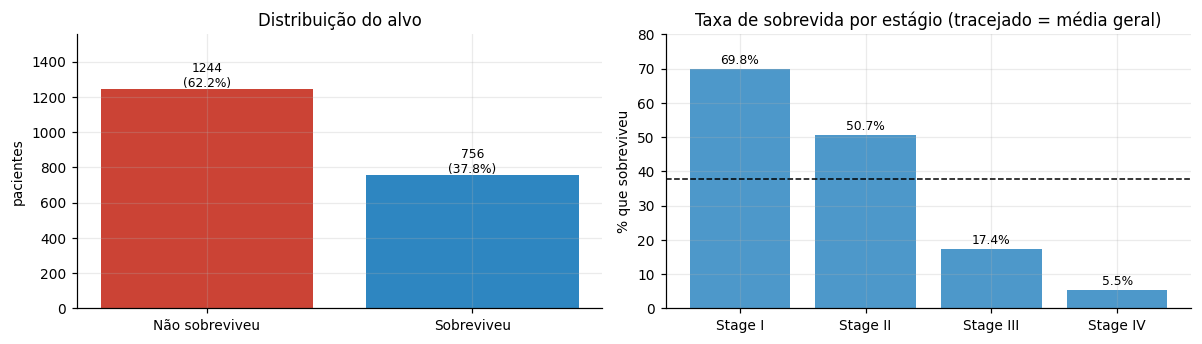

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.2))

vc = df[TARGET].value_counts()
axes[0].bar(["Não sobreviveu", "Sobreviveu"], [vc["No"], vc["Yes"]], color=[C_NEG, C_POS])
for i, v in enumerate([vc["No"], vc["Yes"]]):
    axes[0].text(i, v + 15, f"{v}\n({v/len(df):.1%})", ha="center", fontsize=8)
axes[0].set_ylim(0, vc.max() * 1.25)
axes[0].set_title("Distribuição do alvo"); axes[0].set_ylabel("pacientes")

taxa = df.groupby("Cancer_Stage")[TARGET].apply(lambda s: (s == "Yes").mean() * 100)
taxa = taxa.reindex(STAGE_ORDER)
axes[1].bar(taxa.index, taxa.values, color=C_POS, alpha=0.85)
for i, v in enumerate(taxa.values):
    axes[1].text(i, v + 1.5, f"{v:.1f}%", ha="center", fontsize=8)
axes[1].axhline((df[TARGET] == "Yes").mean() * 100, ls="--", lw=1, color="black")
axes[1].set_ylim(0, 80)
axes[1].set_title("Taxa de sobrevida por estágio (tracejado = média geral)")
axes[1].set_ylabel("% que sobreviveu")

plt.tight_layout(); plt.show()

In [17]:
from scipy.stats import chi2_contingency

assoc = {}
for c in CATEGORICAL_FEATURES + BINARY_FEATURES:
    tab = pd.crosstab(df[c], df[TARGET])
    chi2 = chi2_contingency(tab)[0]
    assoc[c] = np.sqrt(chi2 / (tab.values.sum() * (min(tab.shape) - 1)))

cramer = pd.Series(assoc).sort_values(ascending=False)
print("V de Cramér — associação de cada variável com o alvo (top 8):\n")
print(cramer.head(8).round(4).to_string())
print("\n-> O estágio domina. A segunda colocada (Metastasis) é praticamente")
print("   uma reescrita do estágio IV. Da terceira em diante, a associação é fraca.")

V de Cramér — associação de cada variável com o alvo (top 8):

Cancer_Stage              0.5384
Metastasis                0.3810
Diagnosis_Method          0.2020
Smoking_Status            0.1366
Genetic_Mutation          0.0766
Chronic_Lung_Disease      0.0676
Coughing_Blood            0.0660
Air_Pollution_Exposure    0.0620

-> O estágio domina. A segunda colocada (Metastasis) é praticamente
   uma reescrita do estágio IV. Da terceira em diante, a associação é fraca.


---
## 4. Vazamento de dados

Duas colunas do arquivo **não podem** entrar no modelo:

| Coluna | Tipo de vazamento | Por quê |
|---|---|---|
| `Survival_Months` | de alvo | é o próprio desfecho em outra escala — só existe depois que o desfecho ocorreu |
| `Treatment` | temporal | o tratamento é decidido *depois* do diagnóstico; `Palliative Care` codifica o prognóstico do próprio médico |

A célula abaixo mostra a evidência e constrói a matriz de atributos já sem elas. A remoção
acontece **antes da divisão treino/teste**, para que nenhuma etapa posterior possa
reintroduzi-las por acidente.

In [18]:
from sklearn.metrics import roc_auc_score

y_all = (df[TARGET] == "Yes").astype(int)

# (a) poder preditivo de uma variável que não deveria existir no diagnóstico
print(f"Survival_Months sozinho -> ROC-AUC = {roc_auc_score(y_all, df.Survival_Months):.4f}")

# (b) prova temporal: sobrevida maior que o seguimento fisicamente possível
ano_corte = df.Diagnosis_Year.max()
seguimento_max = 12 * (ano_corte - df.Diagnosis_Year) + 12
impossivel = df.Survival_Months > seguimento_max
print(f"Pacientes com sobrevida > seguimento possível: {impossivel.sum()} "
      f"({impossivel.mean():.1%})")
print("-> um paciente diagnosticado em 2026 não pode ter 100 meses de sobrevida.\n")

# (c) 'Palliative Care' é o prognóstico do médico, não um dado do diagnóstico
print("Taxa de sobrevida por tratamento:")
print(df.groupby("Treatment")[TARGET].apply(lambda s: (s == "Yes").mean() * 100)
        .round(1).sort_values().to_string())

# ---------------- matriz de atributos, já sem vazamento ----------------
y = df[TARGET].map(TARGET_MAP).astype(int)
X = df.drop(columns=[TARGET] + DROP_ALWAYS)

proibidas = [c for c in DROP_ALWAYS if c in X.columns]
assert not proibidas, f"coluna proibida sobreviveu: {proibidas}"
print(f"\nMatriz de atributos: {X.shape[0]} pacientes x {X.shape[1]} variáveis (sem vazamento)")

Survival_Months sozinho -> ROC-AUC = 0.7775
Pacientes com sobrevida > seguimento possível: 437 (21.9%)
-> um paciente diagnosticado em 2026 não pode ter 100 meses de sobrevida.

Taxa de sobrevida por tratamento:
Treatment
Palliative Care           13.7
Chemo + Radiation         14.6
Chemotherapy              19.6
Immunotherapy             24.5
Targeted Therapy          29.0
Radiotherapy              46.3
Surgery + Chemotherapy    52.4
Surgery                   64.9

Matriz de atributos: 2000 pacientes x 38 variáveis (sem vazamento)


---
## 5. Pré-processamento

Todo o pré-processamento vive **dentro do `Pipeline`**. Isso é o que impede o segundo tipo de
vazamento: vocabulários de categorias e estatísticas são aprendidos apenas nos folds de
treino, nunca no conjunto inteiro.

| Grupo | N | Transformação | Por quê |
|---|---|---|---|
| Numéricas | 9 | nenhuma | árvores são invariantes a escala — padronizar seria custo sem retorno |
| Binárias | 18 | `OrdinalEncoder` (`No`=0, `Yes`=1) | categorias fixadas para não mudarem entre folds |
| Ordinais | 5 | `OrdinalEncoder` na ordem clínica | `Stage I < II < III < IV`; assim um corte `<= 1.5` significa "estágio inicial" |
| Nominais | 6 | `OneHotEncoder` | sem ordem natural; `min_frequency=10` agrupa níveis raros |

In [19]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder

ordinal_cols = list(ORDINAL_SPEC)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", "passthrough", NUMERIC_FEATURES),
        ("bin", OrdinalEncoder(categories=[["No", "Yes"]] * len(BINARY_FEATURES)),
                BINARY_FEATURES),
        ("ord", OrdinalEncoder(categories=[ORDINAL_SPEC[c] for c in ordinal_cols]),
                ordinal_cols),
        ("nom", OneHotEncoder(handle_unknown="infrequent_if_exist", min_frequency=10,
                              sparse_output=False), NOMINAL),
    ],
    remainder="drop",                 # qualquer coluna não declarada é descartada
    verbose_feature_names_out=False,
)

nomes_attr = list(preprocessor.fit(X).get_feature_names_out())
print(f"{X.shape[1]} variáveis originais -> {len(nomes_attr)} atributos após codificação\n")
print("Codificação do estágio (importante para ler a árvore depois):")
for i, s in enumerate(STAGE_ORDER):
    print(f"   {s:<10} -> {i}")

38 variáveis originais -> 63 atributos após codificação

Codificação do estágio (importante para ler a árvore depois):
   Stage I    -> 0
   Stage II   -> 1
   Stage III  -> 2
   Stage IV   -> 3


---
## 6. Divisão treino / teste

Hold-out estratificado 80/20. O conjunto de teste fica reservado e só será tocado na seção 9,
uma única vez, para reportar. Toda escolha (profundidade, critério, tamanho mínimo de folha)
é feita por validação cruzada **dentro do treino**.

In [20]:
from sklearn.model_selection import StratifiedKFold, train_test_split

X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
)

# os dois conjuntos precisam ser disjuntos
assert len(set(X_tr.index) & set(X_te.index)) == 0, "treino e teste se sobrepõem"

CV = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

print(f"Treino: {len(X_tr):>5} pacientes  ({y_tr.mean():.1%} positivos)")
print(f"Teste : {len(X_te):>5} pacientes  ({y_te.mean():.1%} positivos)")

Treino:  1600 pacientes  (37.8% positivos)
Teste :   400 pacientes  (37.8% positivos)


---
## 7. A árvore sem controle de complexidade

Primeiro, dois pontos de referência:

- **Baseline** — prevê sempre a classe majoritária. É o piso: qualquer modelo precisa superá-lo.
- **Árvore com parâmetros padrão** — cresce sem limite, até isolar cada paciente numa folha.

O resultado da segunda é o exemplo clássico de **sobreajuste**: desempenho perfeito no treino
e ruim na validação.

In [21]:
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import cross_validate
from sklearn.tree import DecisionTreeClassifier

# Pré-processamento + modelo, num objeto só
def montar_pipeline(estimador):
    return Pipeline([("prep", preprocessor), ("clf", estimador)])

candidatos = {
    "Baseline (classe majoritária)": DummyClassifier(strategy="prior"),
    "Árvore sem limite (padrão)": DecisionTreeClassifier(
        random_state=RANDOM_STATE, class_weight="balanced"),
}

linhas = []
for nome, est in candidatos.items():
    sc = cross_validate(montar_pipeline(est), X_tr, y_tr, cv=CV,
                        scoring=SCORING, return_train_score=True)
    linhas.append({"modelo": nome,
                   "cv_roc_auc": sc["test_score"].mean(),
                   "treino_roc_auc": sc["train_score"].mean(),
                   "gap": sc["train_score"].mean() - sc["test_score"].mean()})

display(pd.DataFrame(linhas).set_index("modelo").round(4))

print("\nO 'gap' é a diferença treino - validação: quanto do desempenho NÃO se transfere")
print("para dados novos. A árvore sem limite acerta tudo no treino e desaba na validação:")
print("ela memorizou os pacientes em vez de aprender o padrão.")

,cv_roc_auc,treino_roc_auc,gap
modelo,,,
Baseline (classe majoritária),0.500,0.5,0.000
Árvore sem limite (padrão),0.639,1.0,0.361



O 'gap' é a diferença treino - validação: quanto do desempenho NÃO se transfere
para dados novos. A árvore sem limite acerta tudo no treino e desaba na validação:
ela memorizou os pacientes em vez de aprender o padrão.


---
## 8. Ajuste dos hiperparâmetros

**Hiperparâmetro** é o que você escolhe *antes* do treino, em oposição ao que o algoritmo
aprende sozinho (nesta árvore, quais variáveis cortar e em que limiares). Três deles
controlam a complexidade:

| Hiperparâmetro | O que controla |
|---|---|
| `max_depth` | quantos níveis a árvore pode crescer |
| `min_samples_leaf` | mínimo de pacientes em cada folha |
| `criterion` | como medir a qualidade de um corte (`gini` ou `entropy`) |

O `GridSearchCV` testa todas as combinações, cada uma avaliada por validação cruzada de 5
folds **no treino**. Usar o teste aqui seria vazamento: o teste passaria a participar da
construção do modelo.

In [22]:
from sklearn.model_selection import GridSearchCV

GRADE = {
    "clf__max_depth":        [2, 3, 4, 5, 6, 8, None],
    "clf__min_samples_leaf": [1, 5, 10, 20, 40],
    "clf__criterion":        ["gini", "entropy"],
}
print(f"Combinações testadas: {7 * 5 * 2} x {N_SPLITS} folds = {7*5*2*N_SPLITS} treinos\n")

busca = GridSearchCV(
    montar_pipeline(DecisionTreeClassifier(random_state=RANDOM_STATE,
                                           class_weight="balanced")),
    GRADE, cv=CV, scoring=SCORING, n_jobs=-1, return_train_score=True,
).fit(X_tr, y_tr)

print("Melhores hiperparâmetros:")
for k, v in sorted(busca.best_params_.items()):
    print(f"   {k.replace('clf__', '')} = {v}")
print(f"\nROC-AUC na validação cruzada: {busca.best_score_:.4f}")

modelo = busca.best_estimator_
arvore = modelo.named_steps["clf"]
print(f"Árvore escolhida: profundidade {arvore.get_depth()}, {arvore.get_n_leaves()} folhas")

Combinações testadas: 70 x 5 folds = 350 treinos

Melhores hiperparâmetros:
   criterion = gini
   max_depth = 2
   min_samples_leaf = 1

ROC-AUC na validação cruzada: 0.8132
Árvore escolhida: profundidade 2, 4 folhas


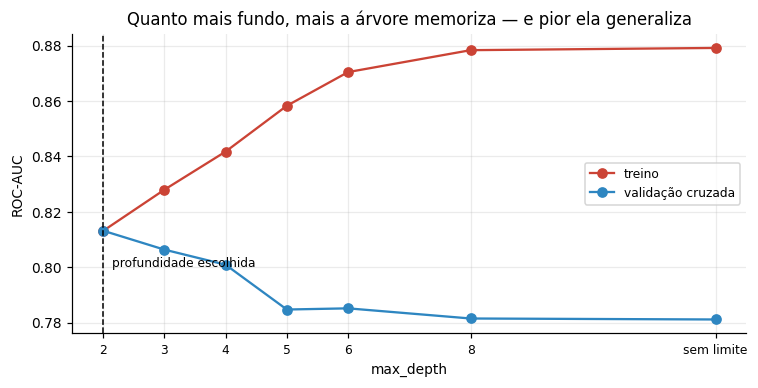

As duas curvas se afastam à medida que a árvore cresce: o treino sobe, a validação
cai. Esse afastamento É o sobreajuste. O melhor ponto é o topo da curva azul.


In [23]:
# Como a profundidade afeta treino e validação (demais hiperparâmetros fixos)
res = pd.DataFrame(busca.cv_results_)
sel = res[(res["param_clf__criterion"] == "gini") &
          (res["param_clf__min_samples_leaf"] == 20)].copy()
sel["prof"] = sel["param_clf__max_depth"].apply(lambda v: 12 if v is None else v)
sel = sel.sort_values("prof")

fig, ax = plt.subplots(figsize=(7, 3.6))
ax.plot(sel.prof, sel.mean_train_score, "o-", color=C_NEG, label="treino")
ax.plot(sel.prof, sel.mean_test_score, "o-", color=C_POS, label="validação cruzada")
ax.axvline(arvore.get_depth(), ls="--", lw=1, color="black")
ax.text(arvore.get_depth() + 0.15, 0.80, "profundidade escolhida", fontsize=8)
ax.set_xticks(sel.prof)
ax.set_xticklabels([("sem limite" if p == 12 else str(p)) for p in sel.prof], fontsize=8)
ax.set_xlabel("max_depth"); ax.set_ylabel("ROC-AUC")
ax.set_title("Quanto mais fundo, mais a árvore memoriza — e pior ela generaliza")
ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

print("As duas curvas se afastam à medida que a árvore cresce: o treino sobe, a validação")
print("cai. Esse afastamento É o sobreajuste. O melhor ponto é o topo da curva azul.")

---
## 9. Avaliação no conjunto de teste

Agora, e só agora, o teste é usado — uma única vez. Nenhuma decisão deste notebook foi tomada
olhando para ele.

As métricas reportadas:

- **ROC-AUC** — probabilidade de o modelo dar escore maior a um sobrevivente do que a um não
  sobrevivente. Não depende do limiar de decisão.
- **Revocação (recall)** — dos que sobreviveram, quantos o modelo identificou.
- **Precisão** — dos que o modelo disse que sobreviveriam, quantos de fato sobreviveram.
- **F1** — média harmônica das duas.
- **Acurácia balanceada** — média do acerto em cada classe; não é enganada pelo desbalanceamento.

In [24]:
from sklearn.metrics import (accuracy_score, balanced_accuracy_score,
                             classification_report, confusion_matrix, f1_score,
                             precision_score, recall_score)

def metricas(y_true, y_proba, limiar=0.5):
    y_pred = (y_proba >= limiar).astype(int)
    return {"roc_auc": roc_auc_score(y_true, y_proba),
            "acuracia": accuracy_score(y_true, y_pred),
            "acuracia_balanceada": balanced_accuracy_score(y_true, y_pred),
            "precisao": precision_score(y_true, y_pred, zero_division=0),
            "revocacao": recall_score(y_true, y_pred, zero_division=0),
            "f1": f1_score(y_true, y_pred, zero_division=0)}

p_tr = modelo.predict_proba(X_tr)[:, 1]
p_te = modelo.predict_proba(X_te)[:, 1]

display(pd.DataFrame({"Treino": metricas(y_tr, p_tr),
                      "Teste (hold-out)": metricas(y_te, p_te)}).round(4))

print("\nMatriz de confusão (teste):")
cm = confusion_matrix(y_te, (p_te >= 0.5).astype(int))
print(pd.DataFrame(cm, index=["Real: não sobreviveu", "Real: sobreviveu"],
                   columns=["Prev: não sobrevive", "Prev: sobrevive"]).to_string())
print("\n" + classification_report(y_te, (p_te >= 0.5).astype(int),
                                   target_names=["Não sobreviveu", "Sobreviveu"], digits=3))
print("O gap entre treino e teste é pequeno — sinal de que a árvore não está memorizando.")

,Treino,Teste (hold-out)
roc_auc,0.8131,0.7789
acuracia,0.7475,0.7100
acuracia_balanceada,0.7704,0.7358
precisao,0.6189,0.5799
revocacao,0.8645,0.8411
f1,0.7214,0.6865



Matriz de confusão (teste):
                      Prev: não sobrevive  Prev: sobrevive
Real: não sobreviveu                  157               92
Real: sobreviveu                       24              127

                precision    recall  f1-score   support

Não sobreviveu      0.867     0.631     0.730       249
    Sobreviveu      0.580     0.841     0.686       151

      accuracy                          0.710       400
     macro avg      0.724     0.736     0.708       400
  weighted avg      0.759     0.710     0.714       400

O gap entre treino e teste é pequeno — sinal de que a árvore não está memorizando.


---
## 10. A árvore desenhada

Esta é a razão de escolher uma árvore. O desenho abaixo **é** o modelo — não é uma
aproximação nem um resumo dele. Qualquer predição pode ser reproduzida à mão seguindo os
ramos.

**Como ler cada nó:**

- a primeira linha é a **pergunta**; se a resposta for verdadeira, desce-se à esquerda;
- `samples` é quantos pacientes do treino passaram por ali;
- `value` é a contagem ponderada `[não sobreviveu, sobreviveu]`;
- a cor indica a classe majoritária, e a intensidade indica a pureza do nó.

Lembre-se da codificação da seção 5: `Cancer_Stage` vale 0 para Stage I, 1 para Stage II,
2 para Stage III e 3 para Stage IV. Então um corte `Cancer_Stage <= 1.5` separa
**estágios iniciais (I e II)** de **estágios avançados (III e IV)**.

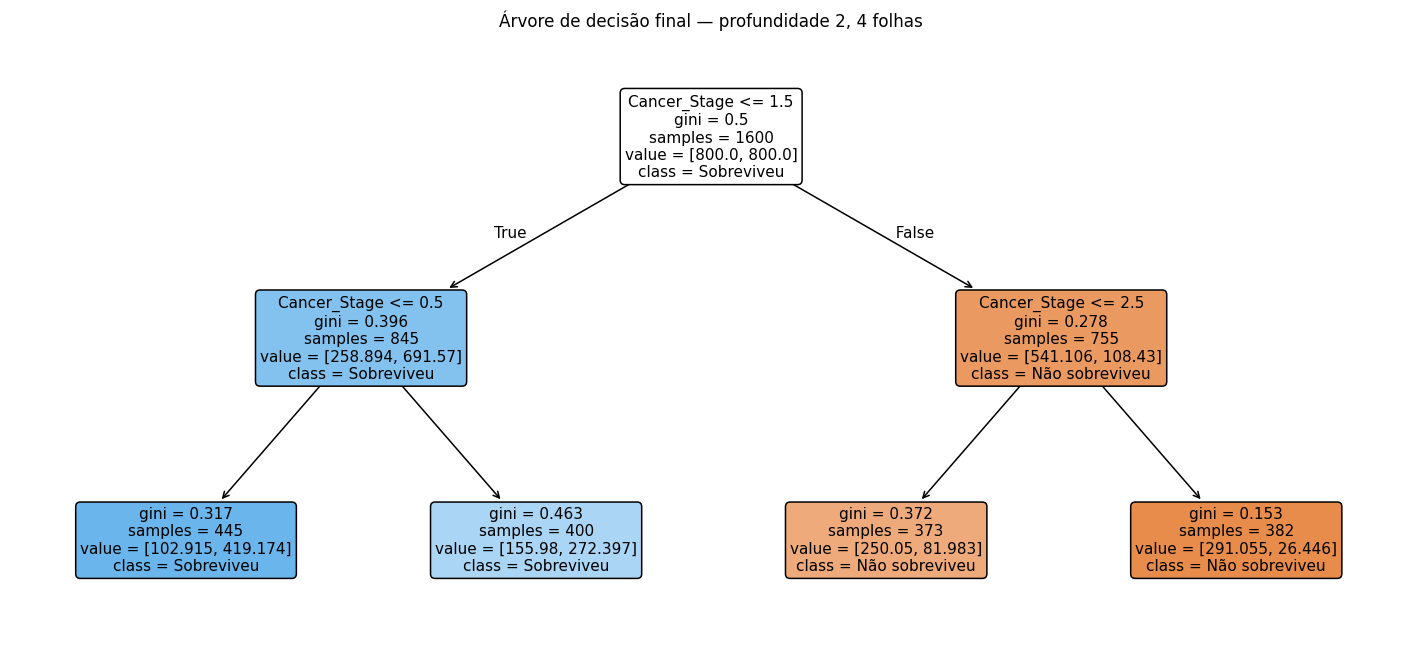

In [25]:
from sklearn.tree import plot_tree

fig, ax = plt.subplots(figsize=(13, 6))
plot_tree(
    arvore,
    feature_names=nomes_attr,
    class_names=["Não sobreviveu", "Sobreviveu"],
    filled=True, rounded=True, proportion=False, fontsize=10, ax=ax,
)
ax.set_title(f"Árvore de decisão final — profundidade {arvore.get_depth()}, "
             f"{arvore.get_n_leaves()} folhas", fontsize=11)
plt.tight_layout(); plt.show()

In [26]:
from sklearn.tree import export_text

print("As mesmas regras em texto:\n")
print(export_text(arvore, feature_names=nomes_attr, decimals=2))

print("Probabilidade de sobrevida prevista, por estágio:\n")
saida = pd.DataFrame({"estágio": df.loc[X_te.index, "Cancer_Stage"],
                      "prob_prevista": p_te.round(3),
                      "sobreviveu": y_te.values})
resumo = (saida.groupby("estágio")
                .agg(pacientes=("prob_prevista", "size"),
                     prob_prevista=("prob_prevista", "first"),
                     taxa_real=("sobreviveu", "mean"))
                .reindex(STAGE_ORDER).round(3))
display(resumo)
print("\nTodos os pacientes de um mesmo estágio recebem a MESMA probabilidade: a árvore")
print("final tem 4 folhas, uma por estágio. Ela é, literalmente, uma tabela de 4 linhas.")

As mesmas regras em texto:

|--- Cancer_Stage <= 1.50
|   |--- Cancer_Stage <= 0.50
|   |   |--- class: 1
|   |--- Cancer_Stage >  0.50
|   |   |--- class: 1
|--- Cancer_Stage >  1.50
|   |--- Cancer_Stage <= 2.50
|   |   |--- class: 0
|   |--- Cancer_Stage >  2.50
|   |   |--- class: 0

Probabilidade de sobrevida prevista, por estágio:



,pacientes,prob_prevista,taxa_real
estágio,,,
Stage I,132,0.803,0.652
Stage II,87,0.636,0.471
Stage III,87,0.247,0.207
Stage IV,94,0.083,0.064



Todos os pacientes de um mesmo estágio recebem a MESMA probabilidade: a árvore
final tem 4 folhas, uma por estágio. Ela é, literalmente, uma tabela de 4 linhas.


### 10.1 E se deixássemos a árvore crescer mais?

A árvore escolhida é rasa porque foi isso que a validação cruzada pediu. Vale ver o que
acontece ao forçar mais profundidade: a árvore passa a cortar em idade, carga tabágica,
sintomas — e o desempenho no teste **piora**. Os cortes extras estão descrevendo ruído do
conjunto de treino, não um padrão real.

ROC-AUC no teste — árvore escolhida (prof. 2): 0.7789
ROC-AUC no teste — árvore forçada  (prof. 4): 0.7719   <- pior



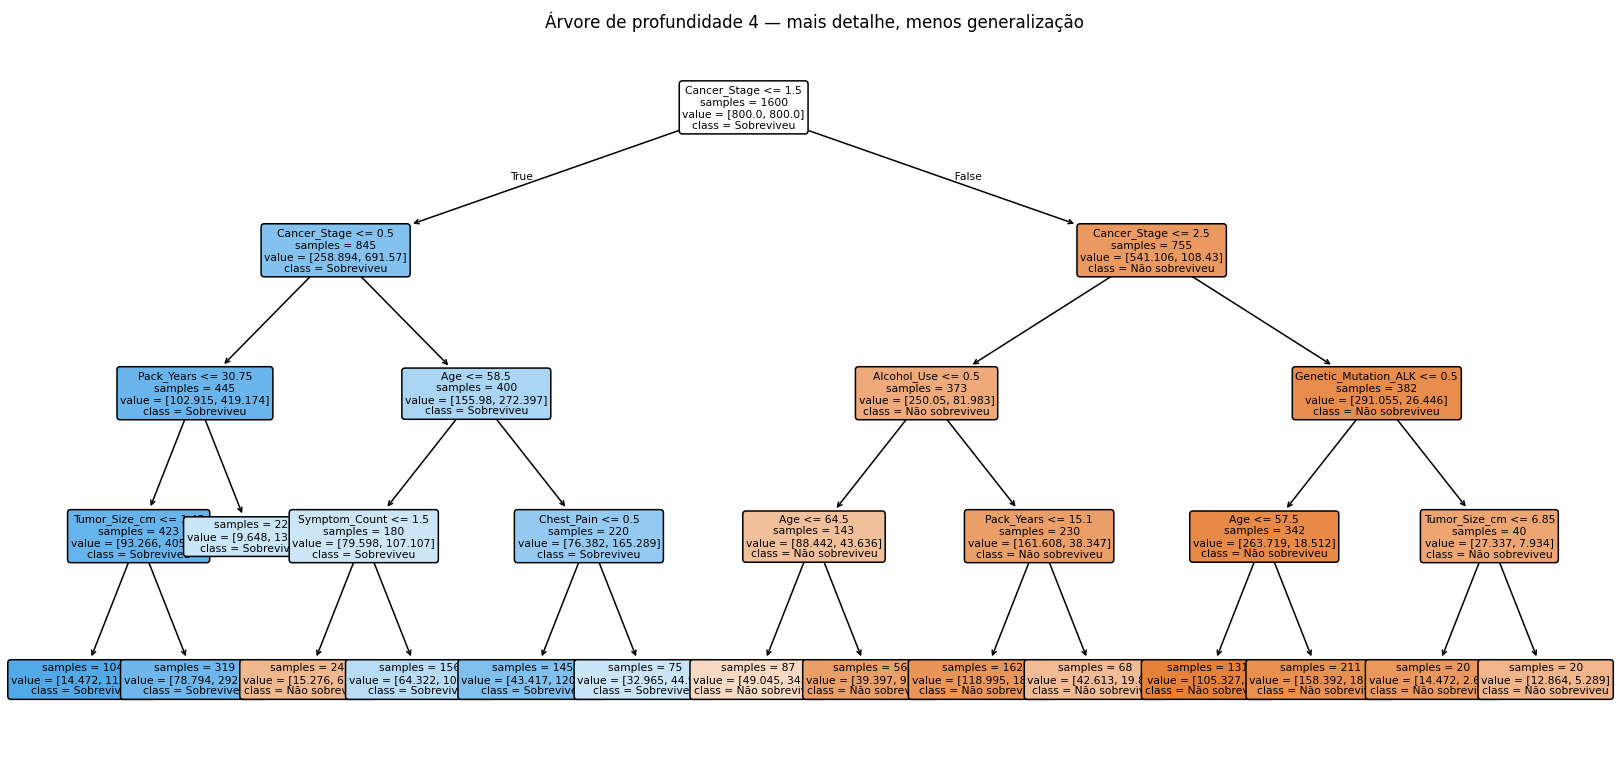

In [27]:
modelo_fundo = montar_pipeline(
    DecisionTreeClassifier(max_depth=4, min_samples_leaf=20,
                           random_state=RANDOM_STATE, class_weight="balanced")
).fit(X_tr, y_tr)
arvore_fundo = modelo_fundo.named_steps["clf"]

auc_fundo = roc_auc_score(y_te, modelo_fundo.predict_proba(X_te)[:, 1])
print(f"ROC-AUC no teste — árvore escolhida (prof. {arvore.get_depth()}): "
      f"{roc_auc_score(y_te, p_te):.4f}")
print(f"ROC-AUC no teste — árvore forçada  (prof. 4): {auc_fundo:.4f}   <- pior\n")

fig, ax = plt.subplots(figsize=(15, 7))
plot_tree(arvore_fundo, feature_names=nomes_attr,
          class_names=["Não sobreviveu", "Sobreviveu"],
          filled=True, rounded=True, fontsize=7, ax=ax, impurity=False)
ax.set_title("Árvore de profundidade 4 — mais detalhe, menos generalização", fontsize=11)
plt.tight_layout(); plt.show()

---
## 11. Importância das variáveis

A árvore expõe diretamente quanto cada variável contribuiu para reduzir a impureza dos nós.
O resultado confirma o que o V de Cramér já sugeria na seção 3.

Atributos disponíveis : 63
Atributos efetivamente usados pela árvore: 1

Cancer_Stage    1.0


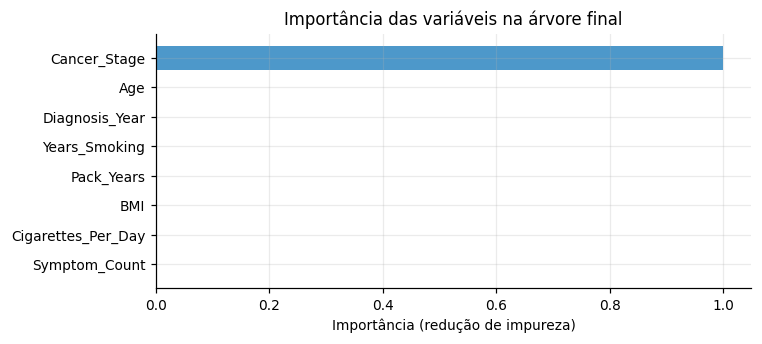

In [28]:
imp = (pd.Series(arvore.feature_importances_, index=nomes_attr)
         .sort_values(ascending=False))
usadas = imp[imp > 0]

print(f"Atributos disponíveis : {len(nomes_attr)}")
print(f"Atributos efetivamente usados pela árvore: {len(usadas)}\n")
print(usadas.round(4).to_string())

fig, ax = plt.subplots(figsize=(7, 3.2))
top = imp.head(8).iloc[::-1]
ax.barh(top.index, top.values, color=C_POS, alpha=0.85)
ax.set_xlabel("Importância (redução de impureza)")
ax.set_title("Importância das variáveis na árvore final")
plt.tight_layout(); plt.show()

---
## 12. Por que o modelo se resume a uma única variável

A árvore final usa apenas `Cancer_Stage`. Antes de aceitar isso como resultado, é preciso
descartar as explicações alternativas. Três perguntas, três experimentos:

| Pergunta | Teste |
|---|---|
| A árvore é simples demais e está deixando sinal na mesa? | **12.1** — outras famílias de modelos, sem restrição de complexidade |
| As outras variáveis importam *dentro* de cada estágio? | **12.2** — um modelo separado por estágio |
| Sem o estágio, o modelo acha outro caminho? | **12.3** — remoção progressiva das variáveis de gravidade |

A célula abaixo prepara um utilitário para avaliar qualquer subconjunto de colunas.

In [29]:
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler

# Mesmo pré-processamento da seção 5, restrito a um subconjunto de colunas
def preprocessador_para(cols, escalar=False):
    num = [c for c in NUMERIC_FEATURES if c in cols]
    bin_ = [c for c in BINARY_FEATURES if c in cols]
    ord_ = [c for c in ORDINAL_SPEC if c in cols]
    nom = [c for c in NOMINAL if c in cols]
    passos = [
        ("num", StandardScaler() if escalar else "passthrough", num),
        ("bin", OrdinalEncoder(categories=[["No", "Yes"]] * len(bin_)), bin_),
        ("ord", OrdinalEncoder(categories=[ORDINAL_SPEC[c] for c in ord_]), ord_),
        ("nom", OneHotEncoder(handle_unknown="infrequent_if_exist", min_frequency=10,
                              sparse_output=False), nom),
    ]
    return ColumnTransformer([p for p in passos if len(p[2]) > 0],
                             remainder="drop", verbose_feature_names_out=False)

# ROC-AUC médio por validação cruzada, usando apenas as colunas indicadas
def auc_cv(cols, estimador, escalar=False, Xd=None, yd=None, cv=CV):
    Xd = X if Xd is None else Xd
    yd = y if yd is None else yd
    pipe = Pipeline([("prep", preprocessador_para(cols, escalar)), ("clf", estimador)])
    return cross_val_score(pipe, Xd[cols], yd, cv=cv, scoring=SCORING).mean()

print("utilitários prontos")

utilitários prontos


### 12.1 A árvore é simples demais?

Se a limitação fosse do modelo, famílias mais flexíveis encontrariam mais sinal. Random Forest
combina centenas de árvores; o boosting corrige erros iterativamente; a regressão logística usa
todos os atributos ao mesmo tempo, em vez de um por corte. Nenhum deles tem a restrição de
profundidade da árvore final.

In [30]:
todas = list(X.columns)

familias = {
    "Árvore (prof. 4)": (DecisionTreeClassifier(max_depth=4, min_samples_leaf=20,
                          random_state=RANDOM_STATE, class_weight="balanced"), False),
    "Random Forest": (RandomForestClassifier(n_estimators=300, min_samples_leaf=8,
                       random_state=RANDOM_STATE, class_weight="balanced_subsample",
                       n_jobs=-1), False),
    "Gradient Boosting": (HistGradientBoostingClassifier(random_state=RANDOM_STATE,
                           max_iter=300, early_stopping=True, class_weight="balanced"), False),
    "Regressão Logística": (LogisticRegression(max_iter=5000, solver="liblinear", C=0.3,
                             class_weight="balanced", random_state=RANDOM_STATE), True),
}

linhas = []
for nome, (est, esc) in familias.items():
    linhas.append({"modelo": nome,
                   "AUC com as 38 variáveis": auc_cv(todas, est, esc),
                   "AUC só com o estágio": auc_cv(["Cancer_Stage"], est, esc)})

display(pd.DataFrame(linhas).set_index("modelo").round(4))
print("\nNenhuma família supera de forma relevante o modelo de uma variável só.")
print("A limitação não está no algoritmo escolhido.")

,AUC com as 38 variáveis,AUC só com o estágio
modelo,,
Árvore (prof. 4),0.7906,0.8058
Random Forest,0.7967,0.8058
Gradient Boosting,0.7908,0.8058
Regressão Logística,0.7964,0.8058



Nenhuma família supera de forma relevante o modelo de uma variável só.
A limitação não está no algoritmo escolhido.


### 12.2 O teste decisivo: existe sinal *dentro* de cada estágio?

Este é o experimento que encerra a questão. Se as outras 37 variáveis carregassem alguma
informação própria, elas conseguiriam separar sobreviventes de não sobreviventes **entre
pacientes do mesmo estágio** — onde o estágio, sendo constante, não ajuda em nada.

Treina-se então um modelo por estrato, usando todas as variáveis **exceto** o estágio.

In [31]:
sem_estagio = [c for c in todas if c != "Cancer_Stage"]
lr = LogisticRegression(max_iter=5000, solver="liblinear", C=0.3,
                        class_weight="balanced", random_state=RANDOM_STATE)

linhas = []
for s in STAGE_ORDER:
    m = df.Cancer_Stage == s
    linhas.append({"estágio": s,
                   "pacientes": int(m.sum()),
                   "taxa de sobrevida": y[m].mean(),
                   "AUC das outras 37 variáveis": auc_cv(sem_estagio, lr, escalar=True,
                                                         Xd=X[m], yd=y[m])})

display(pd.DataFrame(linhas).set_index("estágio").round(4))
print("\nTodos os valores ficam em torno de 0,50 — o mesmo que um sorteio. Dois ficam")
print("ABAIXO de 0,50, o que só acontece por ruído amostral.")
print("\n-> Fixada a gravidade da doença, nenhuma das outras variáveis distingue os pacientes.")

,pacientes,taxa de sobrevida,AUC das outras 37 variáveis
estágio,,,
Stage I,577,0.6984,0.5227
Stage II,487,0.5072,0.4691
Stage III,460,0.1739,0.5008
Stage IV,476,0.0546,0.4401



Todos os valores ficam em torno de 0,50 — o mesmo que um sorteio. Dois ficam
ABAIXO de 0,50, o que só acontece por ruído amostral.

-> Fixada a gravidade da doença, nenhuma das outras variáveis distingue os pacientes.


In [32]:
# A mesma constatação, sem modelo nenhum: sobrevida por nº de sintomas dentro do Stage I
m = df.Cancer_Stage == "Stage I"
tab = (df[m].groupby("Symptom_Count")[TARGET]
            .agg(pacientes="size", taxa=lambda s: (s == "Yes").mean())
            .round(3))
display(tab)
print("\nSem tendência: a taxa sobe e desce sem padrão, e os extremos vêm de grupos pequenos.")

,pacientes,taxa
Symptom_Count,,
0,18,0.722
1,67,0.687
2,148,0.777
3,145,0.683
4,106,0.604
5,62,0.694
6,21,0.857
7,7,0.429
8,3,0.667



Sem tendência: a taxa sobe e desce sem padrão, e os extremos vêm de grupos pequenos.


### 12.3 E se o estágio for removido?

Aqui aparece o resultado mais instrutivo dos três. Sem `Cancer_Stage` o modelo ainda alcança
cerca de 0,75 — o que **parece** indicar sinal independente. Não é: a árvore simplesmente troca
o estágio por variáveis que o espelham.

In [33]:
from scipy.stats import spearmanr

estagio_num = df.Cancer_Stage.map({s: i for i, s in enumerate(STAGE_ORDER)})

print("Correlação de Spearman de cada variável com o ESTÁGIO:\n")
for c in ["Tumor_Size_cm", "Metastasis", "Pack_Years", "Symptom_Count", "Age"]:
    v = df[c] if pd.api.types.is_numeric_dtype(df[c]) else (df[c] == "Yes").astype(int)
    auc_sozinha = roc_auc_score(y_all, -v)
    print(f"   {c:<16} rho = {spearmanr(v, estagio_num).statistic:+.3f}   "
          f"(AUC sozinha = {max(auc_sozinha, 1-auc_sozinha):.3f})")

print("\nTamanho médio do tumor por estágio:")
print(df.groupby("Cancer_Stage").Tumor_Size_cm.mean().reindex(STAGE_ORDER).round(2).to_string())
print("\n-> Tumor_Size_cm é praticamente uma régua do estágio (rho = 0,85).")

Correlação de Spearman de cada variável com o ESTÁGIO:

   Tumor_Size_cm    rho = +0.845   (AUC sozinha = 0.770)
   Metastasis       rho = +0.750   (AUC sozinha = 0.677)
   Pack_Years       rho = +0.251   (AUC sozinha = 0.568)
   Symptom_Count    rho = +0.152   (AUC sozinha = 0.555)
   Age              rho = +0.023   (AUC sozinha = 0.506)

Tamanho médio do tumor por estágio:
Cancer_Stage
Stage I      2.03
Stage II     4.01
Stage III    5.55
Stage IV     7.17

-> Tumor_Size_cm é praticamente uma régua do estágio (rho = 0,85).


In [34]:
arv = DecisionTreeClassifier(max_depth=2, min_samples_leaf=20,
                             random_state=RANDOM_STATE, class_weight="balanced")

GRAVIDADE = ["Cancer_Stage", "Metastasis", "Tumor_Size_cm"]
cenarios = {
    "Todas as 38 variáveis":            todas,
    "Só o estágio":                    ["Cancer_Stage"],
    "Sem estágio":                      sem_estagio,
    "Sem estágio e metástase":          [c for c in todas if c not in GRAVIDADE[:2]],
    "Sem nenhuma medida de gravidade":  [c for c in todas if c not in GRAVIDADE],
}

res = pd.Series({k: auc_cv(v, arv) for k, v in cenarios.items()})
res["Baseline (chute)"] = 0.5
display(res.round(4).to_frame("ROC-AUC (CV)"))

# quais variáveis a árvore passa a usar quando o estágio some
m_sem = Pipeline([("prep", preprocessador_para(sem_estagio)), ("clf", arv)]).fit(
    X[sem_estagio], y)
nomes_sem = list(m_sem.named_steps["prep"].get_feature_names_out())
imp_sem = pd.Series(m_sem.named_steps["clf"].feature_importances_, index=nomes_sem)
print("\nSem o estágio, a árvore passa a cortar em:")
print(imp_sem[imp_sem > 0].sort_values(ascending=False).round(3).to_string())

,ROC-AUC (CV)
Todas as 38 variáveis,0.8058
Só o estágio,0.8058
Sem estágio,0.7629
Sem estágio e metástase,0.7524
Sem nenhuma medida de gravidade,0.5909
Baseline (chute),0.5000



Sem o estágio, a árvore passa a cortar em:
Tumor_Size_cm    0.742
Metastasis       0.258


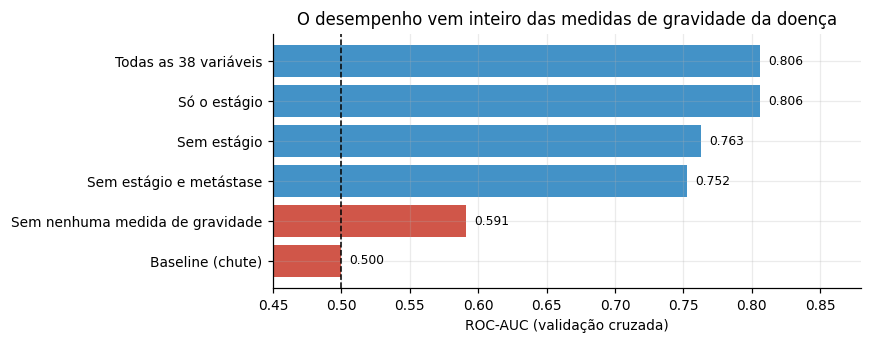

As duas primeiras barras são iguais: 38 variáveis não superam 1 variável.
Removendo estágio, metástase e tamanho do tumor, o modelo colapsa para perto do chute.


In [35]:
fig, ax = plt.subplots(figsize=(8, 3.2))
ordem = res.iloc[::-1]
cores = [C_POS if v >= 0.75 else ("#f39c12" if v >= 0.6 else C_NEG) for v in ordem.values]
ax.barh(ordem.index, ordem.values, color=cores, alpha=0.9)
for i, v in enumerate(ordem.values):
    ax.text(v + 0.006, i, f"{v:.3f}", va="center", fontsize=8)
ax.axvline(0.5, ls="--", lw=1, color="black")
ax.set_xlim(0.45, 0.88); ax.set_xlabel("ROC-AUC (validação cruzada)")
ax.set_title("O desempenho vem inteiro das medidas de gravidade da doença")
plt.tight_layout(); plt.show()

print("As duas primeiras barras são iguais: 38 variáveis não superam 1 variável.")
print("Removendo estágio, metástase e tamanho do tumor, o modelo colapsa para perto do chute.")